In [1]:
import os
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Read the dataset and extract labels and features

In [2]:
df_features = pd.read_csv("feature_presence540.txt", sep=r"\s+", header=None, engine="python", dtype=str)

In [3]:
# Load datasets
df_label = pd.read_excel('aggregateRockData.xlsx', header=None)
df_features = pd.read_csv("feature_presence540.txt", sep=r"\s+", header=None, engine="python", dtype=str).iloc[:540, 2:15]

# Rename columns
df_features.columns = [
    "token number", "Straight stripes",
    "Curved stripes", "Physical layers", "Veins", "Oily/Shimmery texture", 
    "Splotchy", "Single translucent crystal", "Multiple cubic crystals", 
    "Sandy texture", "disj(1,2)", "disj(3,4)", "disj(9,10)"
]

# Extract label column and merge with features
df_final = pd.concat([df_label[[1]].rename(columns={1: 'label'}), df_features], axis=1)
# Convert all object columns to numeric
df_final = df_final.apply(pd.to_numeric, errors='coerce')

### 1. Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Are there any attributes that might require special treatment? If so, what special treatment might they require? [2 points]

**Statistical descriptions and Visualizations**

In [4]:
df_final.describe()

,label,token number,Straight stripes,Curved stripes,Physical layers,Veins,Oily/Shimmery texture,Splotchy,Single translucent crystal,Multiple cubic crystals,Sandy texture,"disj(1,2)","disj(3,4)","disj(9,10)"
count,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,2.000000,9.500000,0.085833,0.077870,0.067241,0.042500,0.165037,0.051389,0.144259,0.141667,0.031019,0.027407,0.120426,0.147148
std,0.817254,5.192938,0.196864,0.192185,0.190793,0.163321,0.217403,0.100338,0.266835,0.167279,0.136093,0.121786,0.175570,0.271611
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,9.500000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.100000,0.000000,0.000000,0.050000,0.000000
75%,3.000000,14.000000,0.050000,0.050000,0.000000,0.000000,0.250000,0.050000,0.100000,0.200000,0.000000,0.000000,0.150000,0.150000
max,3.000000,18.000000,1.000000,1.000000,1.000000,1.000000,0.950000,0.900000,1.000000,0.950000,1.000000,1.000000,1.000000,1.000000


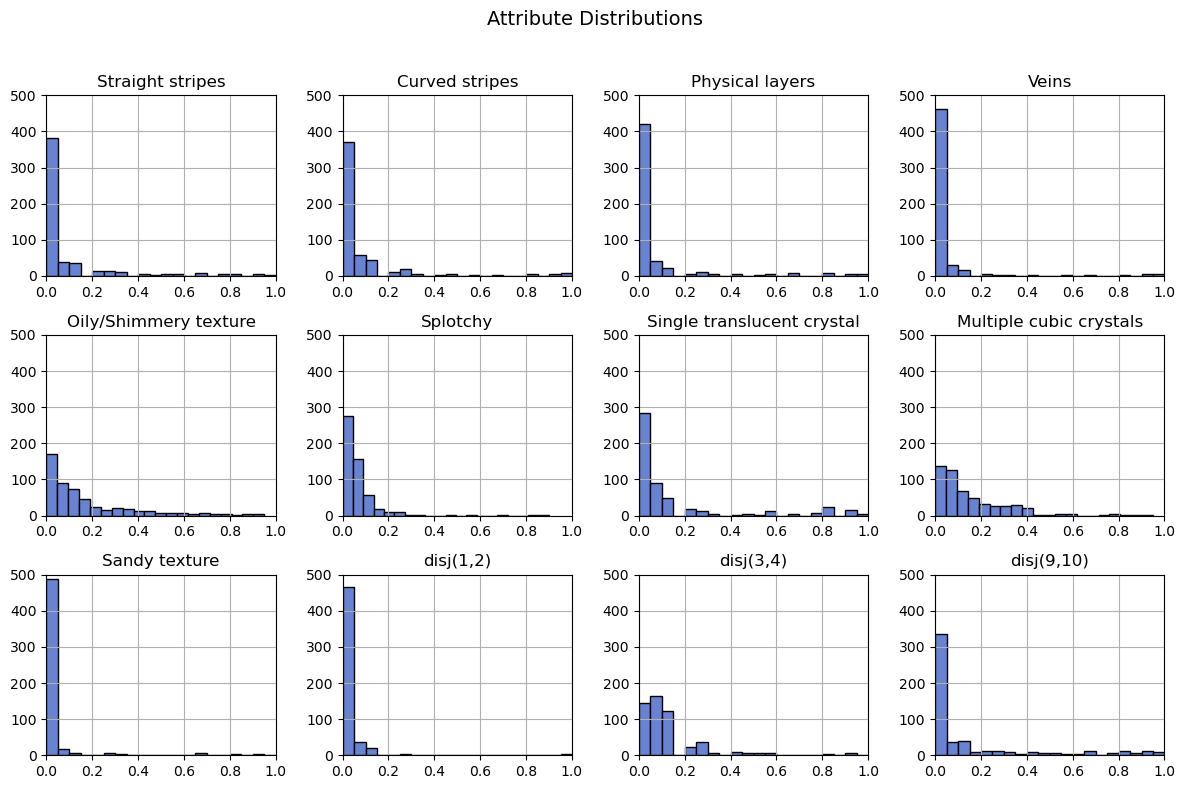

In [5]:
# Drop 'label' since it's categorical and not an attribute for histograms
df_features_only = df_final.drop(columns=["label", "token number"])

# Create subplots with 3 rows and 4 columns
fig, ax = plt.subplots(3, 4, figsize=(12, 8))
fig.suptitle("Attribute Distributions", fontsize=14)

# Flatten the axes array for easy iteration
ax = ax.flatten()

# Plot histograms for each attribute
for i, column in enumerate(df_features_only.columns):
    df_features_only[column].hist(ax=ax[i], bins=20, color='#6883d2', edgecolor='black')
    ax[i].set_title(column)
    ax[i].grid(True)
    
    # Set x-axis and y-axis limits
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 500)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


**Any special treatment required**

Based on the attribute distributions, certain preprocessing steps could be applied to improve the performance of classification models. However, for this project, we will not implement these modifications.

**Handling Skewed Distributions**

Many attributes exhibit right-skewed distributions, meaning most values are clustered near zero with a few larger values. A possible approach would be to apply log transformation or power transformation to normalize the distributions, making them more suitable for machine learning models.

**Addressing Features with Many Zero Values**

Several attributes, such as Sandy texture, disj(1,2), disj(9,10), contain a high proportion of zero values. A potential method to handle this would be to convert these features into binary indicators (0/1) instead of treating them as continuous values. This transformation could help models better differentiate between the presence and absence of these features.

**Managing Outliers**

Some attributes, such as Single translucent crystal, Multiple cubic crystals, disj(3,4), contain a small number of unusually high values, which may act as outliers. Possible treatments could include Winsorization (capping extreme values) or using Robust Scaling, which is less sensitive to extreme values compared to traditional standardization techniques.

**Conclusion**

While these preprocessing steps could help improve model performance by making feature distributions more balanced, we will not implement them in this project. Instead, we will proceed with the raw feature values as provided in the dataset.

### 2. Analyze and discuss the relationships between the data attributes and between the data attributes and labels. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [3 points]

**Computing the PCC**

In [6]:
df_final

,label,token number,Straight stripes,Curved stripes,Physical layers,Veins,Oily/Shimmery texture,Splotchy,Single translucent crystal,Multiple cubic crystals,Sandy texture,"disj(1,2)","disj(3,4)","disj(9,10)"
0,1,1,0.20,0.15,0.00,0.00,0.00,0.05,0.00,0.30,0.0,0.00,0.10,0.32
1,1,2,0.65,0.15,0.00,0.00,0.05,0.00,0.00,0.10,0.0,0.05,0.05,0.70
2,1,3,0.60,0.00,0.00,0.00,0.05,0.00,0.00,0.35,0.0,0.00,0.05,0.60
3,1,4,0.10,0.85,0.00,0.00,0.05,0.00,0.00,0.10,0.0,0.00,0.10,0.86
4,1,5,0.35,0.80,0.00,0.00,0.00,0.00,0.00,0.10,0.0,0.00,0.05,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,3,18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.0,1.00,0.00,0.00
536,3,17,0.00,0.00,0.85,0.05,0.15,0.05,0.00,0.00,0.0,0.00,0.40,0.00
537,3,18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,1.00,0.00
538,3,17,0.00,0.00,0.00,0.00,0.55,0.10,0.05,0.05,0.0,0.00,0.00,0.00


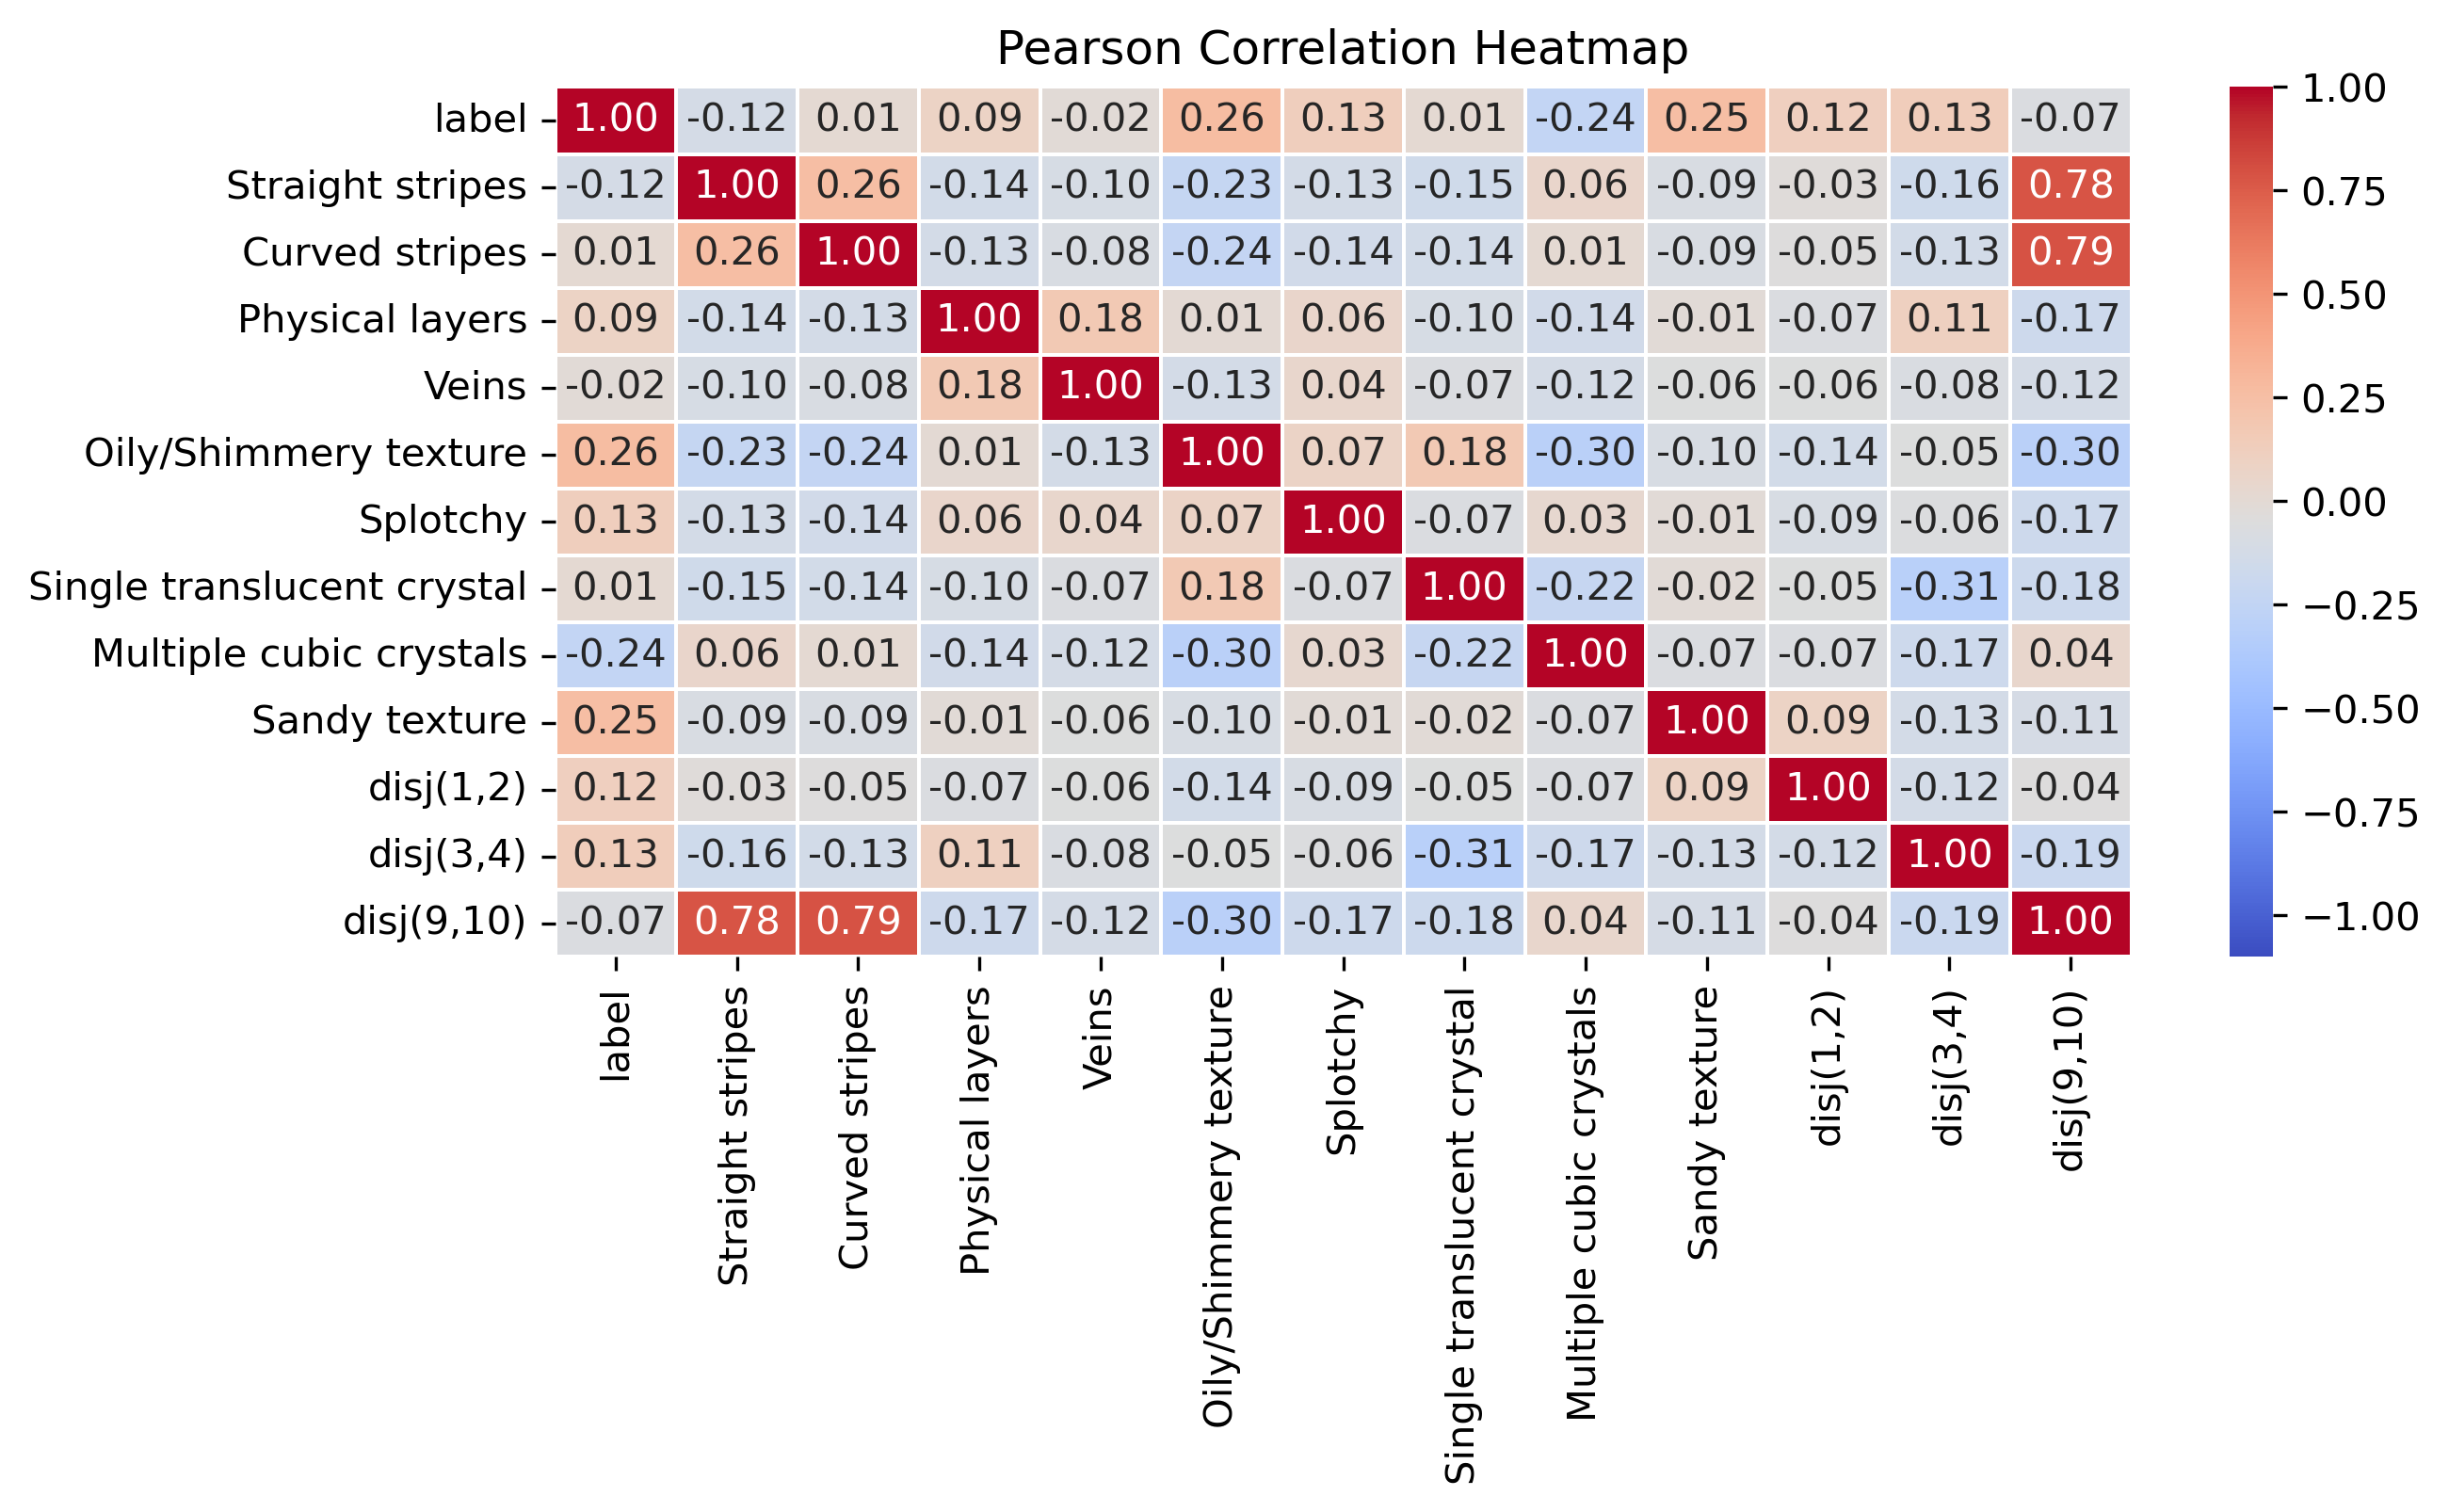

In [7]:
# Drop 'token number' before correlation analysis
df_corr_analysis = df_final.drop(columns=["token number"])

# Compute Pearson Correlation Coefficient (PCC)
correlation_matrix = df_corr_analysis.corr()

# Plot Pearson Correlation Heatmap
fig, axes = plt.subplots(1, 1, figsize=(9, 4), dpi=300)  # Single figure for heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes, vmin=1, vmax=-1)
axes.set_title("Pearson Correlation Heatmap")
plt.show()


**Scatter Plots**

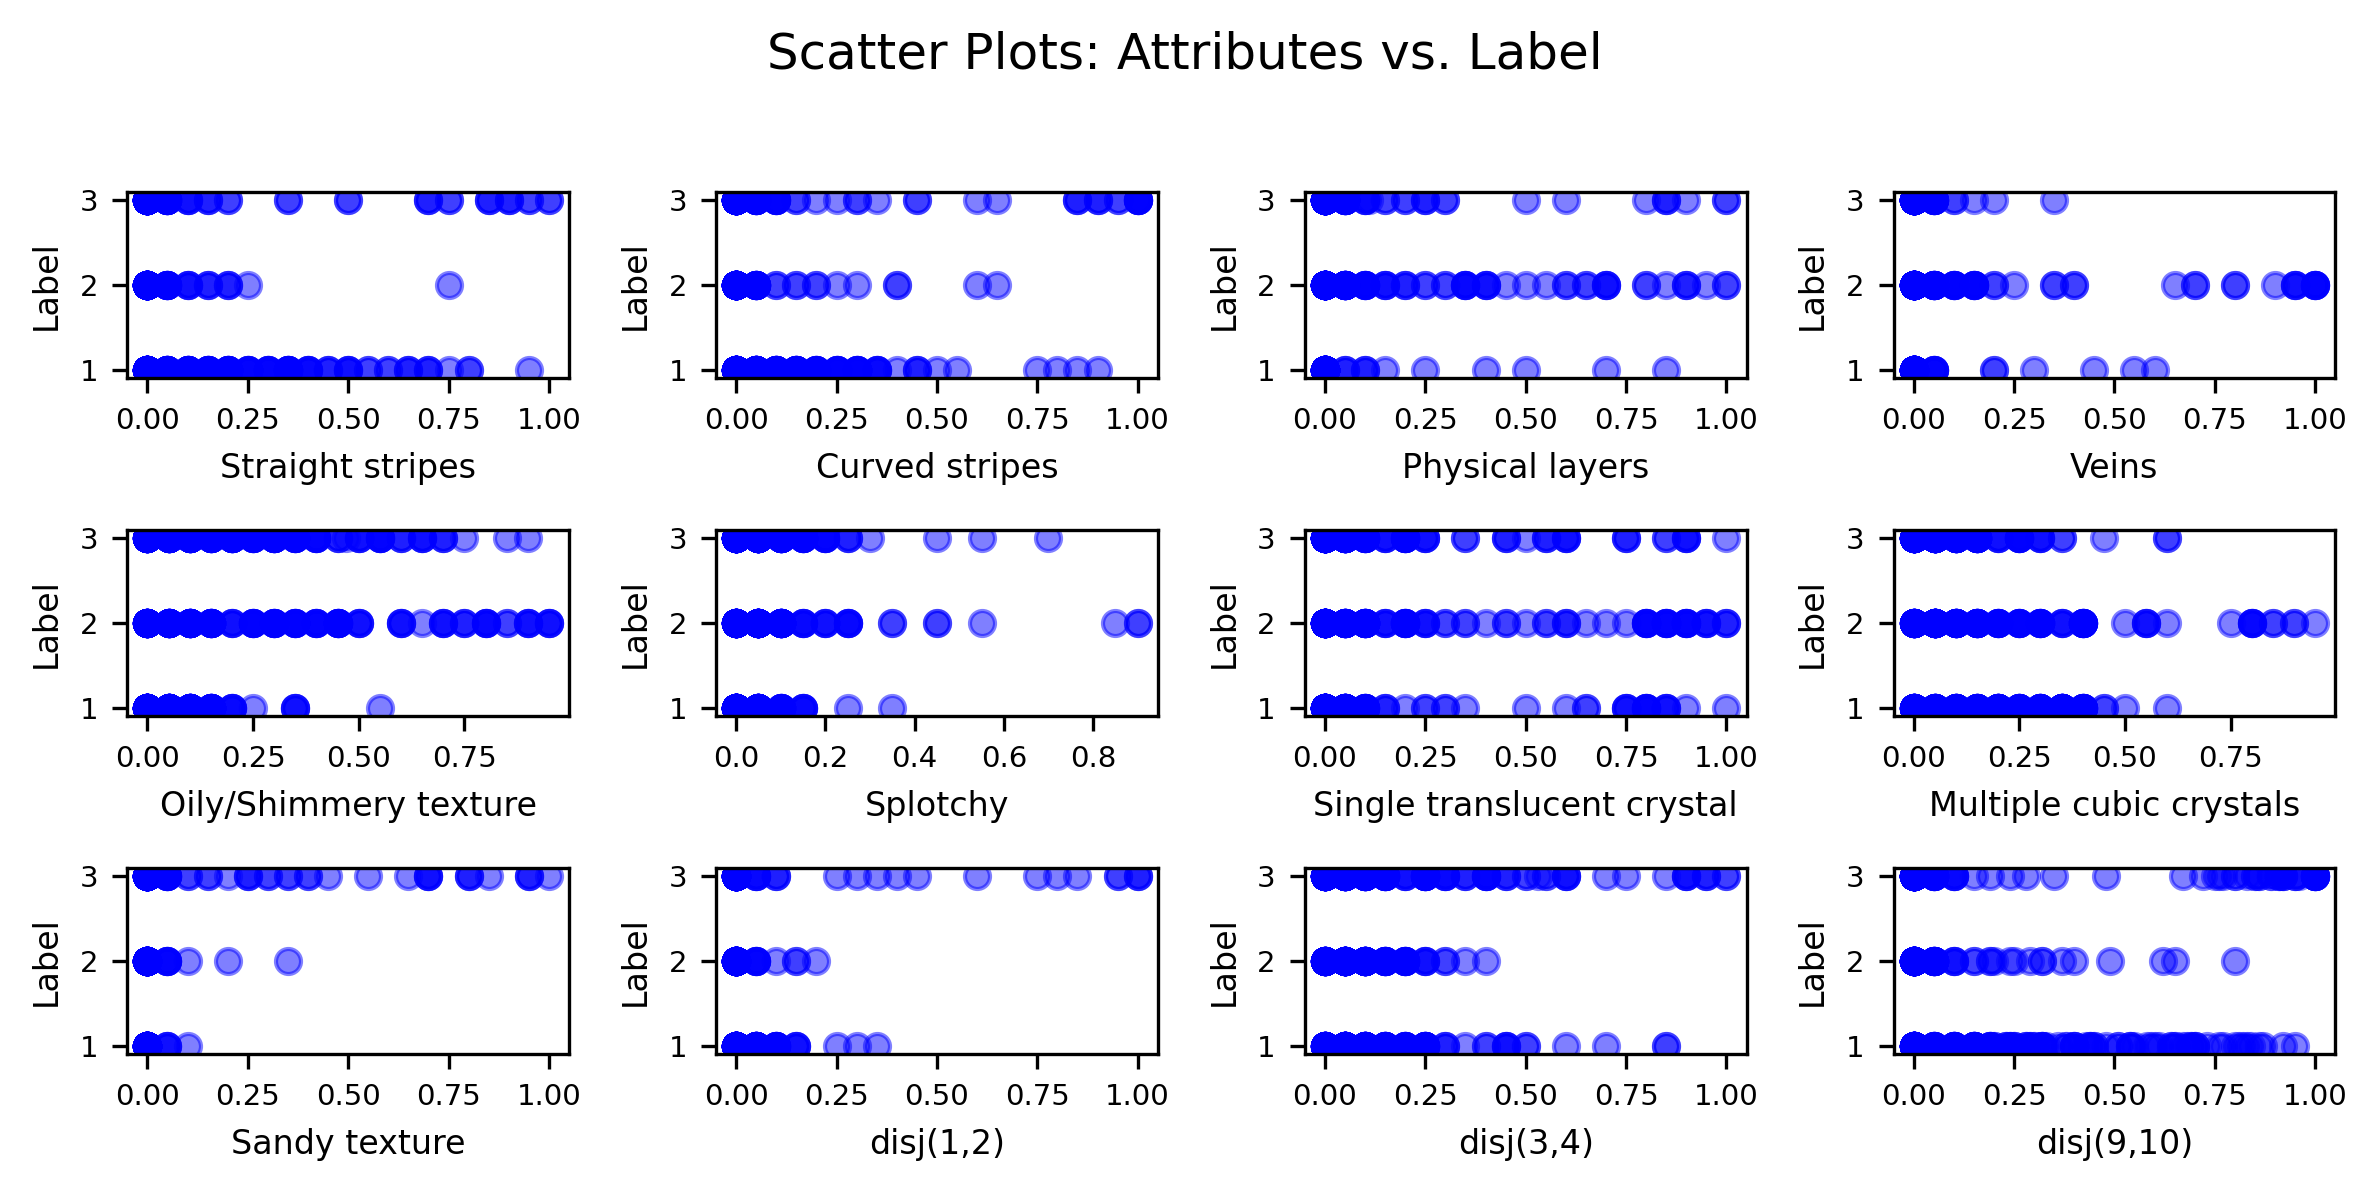

In [8]:
features = df_final.columns[2:]  

fig, axes = plt.subplots(3, 4, figsize=(8, 4), dpi=300)
fig.suptitle("Scatter Plots: Attributes vs. Label", fontsize=12)

axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df_final[feature], df_final["label"], alpha=0.5, color="blue")
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel("Label", fontsize=8)

    axes[i].tick_params(axis='both', labelsize=7)
    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


### 3. For training data, use token numbers 1-10, for validation 11 to 13, and for testing 14 to 16 (each of the 30 rock subtypes has 16 token numbers). [2 points]

**Splitting the data in testing , validation and training sets correctly**

In [9]:
# Drop 'token_number' after using it for splitting
df_final_no_token = df_final.drop(columns=["token number"])

# Assign train, validation, and test data based on token numbers
train_data = df_final[df_final["token number"].between(1, 10)].drop(columns=["token number"])
val_data = df_final[df_final["token number"].between(11, 13)].drop(columns=["token number"])
test_data = df_final[df_final["token number"].between(14, 16)].drop(columns=["token number"])

# Print dataset sizes
print(f"Training set: {train_data.shape}")
print(f"Validation set: {val_data.shape}")
print(f"Testing set: {test_data.shape}")

Training set: (300, 13)
Validation set: (90, 13)
Testing set: (90, 13)


### 4. Train different classifiers and tweak the hyperparameters to improve performance (you can use the grid search if you want or manually try different values). Report training, validation and testing performance (classification accuracy, precision, recall and F1 score) and discuss the impact of the hyperparameters (use markdown cells in Jupyter Notebook to clearly indicate each solution):
- A. Multinomial Logistic Regression (Softmax Regression); hyperparameters to explore: C, solver, max number of iterations. [10 points]
- B. Support Vector Machine (make sure to try using kernels); hyperparameters to explore: C, kernel, degree of polynomial kernel, gamma.  [10 points]
- C. Random Forest classifier (also analyze feature importance); hyperparameters to explore: the number of trees, max depth, the minimum number of samples required to split an internal node, the minimum number of samples required to be at a leaf node. [10 points]

**A. Multinomial Logistic Regression (Softmax Regression); hyperparameters to explore: C, solver, max number of iterations. [10 points]**

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [11]:
# Features and target variables
X = df_final.iloc[:, 1:]  # features
y = df_final.iloc[:,0]   # label

# Divide the dataset by token number
train_idx = df_final.index[df_final['token number'].between(1, 10)]
val_idx = df_final.index[df_final['token number'].between(11, 13)]
test_idx = df_final.index[df_final['token number'].between(14, 16)]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val, y_val = X.loc[val_idx], y.loc[val_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

# Fit StandardScaler using only the training set
scaler = StandardScaler()
scaler.fit(X_train)  

# Transform train, val, test using the same transformation parameters
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Model implementation and Hyperparameter Tuning

In [12]:
# Perform a grid search over C, solver, and max_iter to find the best combination using the validation set.

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
    'max_iter': [500, 1000, 2000]
}

best_val_score = 0
best_params = {}

for C in param_grid['C']:
    for solver in param_grid['solver']:
        for max_iter in param_grid['max_iter']:
            model = LogisticRegression(
                multi_class='multinomial',
                C=C,
                solver=solver,
                max_iter=max_iter,
                random_state=42
            )
            try:
                model.fit(X_train, y_train)
                val_accuracy = model.score(X_val, y_val)
                if val_accuracy > best_val_score:
                    best_val_score = val_accuracy
                    best_params = {'C': C, 'solver': solver, 'max_iter': max_iter}
                    print(f"New best validation accuracy: {best_val_score:.3f} with {best_params}")
            except:
                continue

print("\nBest Parameters:", best_params)
print("Best Validation Accuracy:", best_val_score)

New best validation accuracy: 0.700 with {'C': 0.01, 'solver': 'lbfgs', 'max_iter': 500}
New best validation accuracy: 0.733 with {'C': 0.1, 'solver': 'lbfgs', 'max_iter': 500}
New best validation accuracy: 0.744 with {'C': 0.1, 'solver': 'newton-cg', 'max_iter': 500}
New best validation accuracy: 0.756 with {'C': 1, 'solver': 'lbfgs', 'max_iter': 500}

Best Parameters: {'C': 1, 'solver': 'lbfgs', 'max_iter': 500}
Best Validation Accuracy: 0.7555555555555555


Discussion on the impact of different hyper parameters has been done

**1. Results Explanation**

My grid search tested different combinations of three hyperparameters: C (regularization strength), solver (optimization algorithm), and max_iter (maximum number of iterations). The best parameters found were C=1, solver='lbfgs', and max_iter=500, achieving a validation accuracy of 0.756. As C increased from 0.01 to 1, the validation accuracy gradually improved, but further increasing C did not provide additional benefits. Additionally, 'lbfgs' performed well across different C values, while max_iter=500 was sufficient for training the model without requiring a larger number of iterations.

**2. Influence of Key Hyperparameters**

**Regularization Strength (C)**

- The smaller the C, the stronger the regularization, which enhances generalization but may lead to underfitting. At C=0.01, the validation accuracy was relatively low (0.700).
- At C=0.1, the model performance improved to 0.733.
- At C=1, the highest accuracy of 0.756 was achieved, indicating that reducing regularization moderately can improve model performance.

**Optimization Algorithm (solver)**
  
- 'lbfgs' demonstrated stable performance across all tests, achieving the highest accuracy (0.756) at C=1.
- 'newton-cg' also performed well (0.744) but was slightly inferior to 'lbfgs', suggesting that different solvers adapt differently to the dataset.
- Other solvers (such as 'sag' and 'saga') may not have provided better solutions due to data size or optimization constraints.

**Maximum Number of Iterations (max_iter)**
  
- max_iter=500 was sufficient for model convergence, as increasing it to 1000 or 2000 did not further improve accuracy.
- This indicates that the model found reasonable parameters within 500 iterations, eliminating the need for longer training times.

**3. Summary**
  
The results suggest that moderately reducing regularization (C=1) can improve model performance, while 'lbfgs' is the most stable optimization algorithm, and 500 iterations are sufficient for convergence. For further optimization, finer C values (e.g., 0.5 or 2) could be tested, and cross-validation should be used to ensure the generalizability of the chosen hyperparameters instead of relying solely on a single validation set.

Training, Validation and Testing Performance

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Best model on the training set using best_params
best_model = LogisticRegression(
    multi_class='multinomial',
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=best_params['max_iter'],
    random_state=42
)
best_model.fit(X_train, y_train)

# Evaluate on Training set
y_train_pred = best_model.predict(X_train)
train_acc  = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_rec  = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1   = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("=== Training Performance ===")
print(f"Accuracy:  {train_acc:.3f}")
print(f"Precision: {train_prec:.3f}")
print(f"Recall:    {train_rec:.3f}")
print(f"F1 Score:  {train_f1:.3f}\n")

# Evaluate on Validation set
y_val_pred = best_model.predict(X_val)
val_acc  = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_rec  = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1   = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print("=== Validation Performance ===")
print(f"Accuracy:  {val_acc:.3f}")
print(f"Precision: {val_prec:.3f}")
print(f"Recall:    {val_rec:.3f}")
print(f"F1 Score:  {val_f1:.3f}\n")

# Evaluate on Test set
y_test_pred = best_model.predict(X_test)
test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1   = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("=== Test Performance ===")
print(f"Accuracy:  {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall:    {test_rec:.3f}")
print(f"F1 Score:  {test_f1:.3f}")


=== Training Performance ===
Accuracy:  0.680
Precision: 0.681
Recall:    0.680
F1 Score:  0.680

=== Validation Performance ===
Accuracy:  0.756
Precision: 0.762
Recall:    0.756
F1 Score:  0.751

=== Test Performance ===
Accuracy:  0.733
Precision: 0.733
Recall:    0.733
F1 Score:  0.732


**1. Key Metrics Analysis**
**Training Set vs. Validation Set**

The training accuracy (0.680) is lower than the validation accuracy (0.756), indicating:
- The model performs moderately on the training data and does not exhibit overfitting (otherwise, the training accuracy would be significantly higher than the validation accuracy).
- The relatively low training accuracy may suggest that the dataset itself is complex or that some classes are not well-separated.

**Validation Set vs. Test Set**

The validation accuracy (0.756) is higher than the test accuracy (0.733), indicating:
- The hyperparameter selection achieved optimal performance on the validation set but slightly decreased on the test set.
- This drop suggests that the model may be slightly overfitted to the validation set, meaning the hyperparameter tuning was more tailored to the validation data, leading to slightly worse generalization on unseen test data.

**Comparison of Evaluation Metrics**
- Precision: Measures the proportion of correctly predicted positive samples out of all predicted positives. The precision on the test set is close to the accuracy, indicating that the model maintains a balanced class prediction without favoring a particular class.
- Recall: Measures the proportion of correctly predicted positive samples out of all actual positive samples. The recall remains relatively high, showing that the model effectively identifies most positive instances.
- F1-score: Represents the harmonic mean of precision and recall, ensuring a balance between the two. The F1-score remains above 0.7, indicating that the model is stable and reliable for classification tasks.

**B. Support Vector Machine (make sure to try using kernels); hyperparameters to explore: C, kernel, degree of polynomial kernel, gamma. [10 points]**

Model implementation and hyperparameters Tuning

In [14]:
# GRID SEARCH

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'degree': [2, 3, 4]
}

svm = SVC()

grid_search = GridSearchCV(
    svm,
    param_grid,
    scoring='accuracy',  # could also choose 'f1_weighted', etc.
    cv=3,                # 3-fold cross-validation
    verbose=1,           # to see progress
    n_jobs=-1            # use all processors if possible
)

grid_search.fit(X_train, y_train)

# BEST MODEL + PERFORMANCE

best_svm = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)


Fitting 3 folds for each of 180 candidates, totalling 540 fits
Best Hyperparameters: {'C': 1, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}


After performing a grid search over the hyperparameters ‘C‘,‘kernel‘,‘gamma‘,‘degree‘ on the combined training and validation sets, the best estimator was found to be:

SVC(C=1, kernel='rbf', gamma='scale', degree=2)


Training, Validation and Testing Performance have been reported :3

In [15]:

# Evaluate performance on Training Set (make predictions using best model)
y_train_pred = best_svm.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_rec = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

# Evaluate performance on Validation Set
y_val_pred = best_svm.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_rec = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

# Evaluate performance on Test Set
y_test_pred = best_svm.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

# Print Results
print("=== Training Performance ===")
print(f"Accuracy:  {train_acc:.3f}")
print(f"Precision: {train_prec:.3f}")
print(f"Recall:    {train_rec:.3f}")
print(f"F1 Score:  {train_f1:.3f}\n")

print("=== Validation Performance ===")
print(f"Accuracy:  {val_acc:.3f}")
print(f"Precision: {val_prec:.3f}")
print(f"Recall:    {val_rec:.3f}")
print(f"F1 Score:  {val_f1:.3f}\n")

print("=== Testing Performance ===")
print(f"Accuracy:  {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall:    {test_rec:.3f}")
print(f"F1 Score:  {test_f1:.3f}")

=== Training Performance ===
Accuracy:  0.760
Precision: 0.765
Recall:    0.760
F1 Score:  0.761

=== Validation Performance ===
Accuracy:  0.733
Precision: 0.758
Recall:    0.733
F1 Score:  0.735

=== Testing Performance ===
Accuracy:  0.678
Precision: 0.732
Recall:    0.678
F1 Score:  0.663


Discussion on the impact of different hyperparameters

**Performance Overview**

- From the results, we can see that the model performs best on the training set (0.760), performs slightly worse on the validation set (0.733), and drops further on the test set (0.678).
- This suggests that the model still shows some degree of overfitting, indicating there’s room for improving its generalization ability.
- At the same time, these differences could also reflect distribution discrepancies between the validation and test sets, or issues with data scale and quality.

**Impact of Hyperparameters**

C (Regularization Parameter):
- The best value turned out to be C=1, indicating that a moderate amount of regularization worked best.
- With a larger C (e.g., 10), the SVM tries harder to classify all training points correctly (potentially overfitting). With a smaller C (e.g., 0.1), the decision boundary can be too simple (underfitting).
- In this case, C=1 struck the best balance between fitting the training data and generalizing well.

Kernel:
- My search space included ['linear', 'poly', 'rbf', 'sigmoid'], and ultimately, 'rbf' was selected.
- RBF is especially good at modeling non-linear distributions and often yields strong performance in a variety of scenarios, particularly when the data is not linearly separable.
- If the data were linearly separable, sometimes a 'linear' kernel would perform just as well; however, 'poly' (the polynomial kernel) is quite sensitive to data quantity and feature scaling, making it more challenging to tune. 'sigmoid' is rarely a first choice, generally used only in specific situations or in conjunction with neural networks.

Gamma (Especially important for the RBF kernel):
- Meaning: The gamma parameter controls the “width” or “range of influence” of the Gaussian in the RBF kernel. A large gamma makes the RBF kernel “narrow,” so each training sample has a small range of influence, which often leads to overfitting. Conversely, a smaller gamma makes the RBF kernel “wider,” making the model smoother and more prone to underfitting.
- In my search space ['scale', 'auto', 0.01, 0.1, 1], 0.1 lies around the middle, which can strike a good balance between fitting capacity and generalization ability.
- If gamma=1, it may lead to overfitting; if gamma=0.01, the model might not distinguish the data effectively, causing underfitting.

Degree:
- Although the final hyperparameters include `degree=2`, this parameter is not actually used by the RBF kernel.
- When `kernel='poly'`, the `degree` parameter determines the polynomial order and greatly influences model complexity; however, for the RBF kernel, `degree` is effectively irrelevant.
- The reason “degree=2” appears in the results is that it was included in the parameter grid, and GridSearchCV tested all parameter combinations. Even though RBF was ultimately chosen, the combination still includes `degree=2`, which does not affect the actual RBF kernel.

**C. Random Forest classifier (also analyze feature importance); hyperparameters to explore: the number of trees, max depth, the minimum number of samples required to split an internal node, the minimum number of samples required to be at a leaf node. [10 points]**

In [16]:
# GRID SEARCH
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    scoring='accuracy',  # or 'f1_weighted', 'roc_auc', etc.
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Get the best estimator
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [17]:
# EVALUATE ON TRAIN/VAL/TEST

# Predictions on TRAIN
y_train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_rec = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

# Predictions on VAL
y_val_pred = best_rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_rec = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

# Predictions on TEST
y_test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("=== Training Performance ===")
print(f"Accuracy:  {train_acc:.3f}")
print(f"Precision: {train_prec:.3f}")
print(f"Recall:    {train_rec:.3f}")
print(f"F1 Score:  {train_f1:.3f}\n")

print("=== Validation Performance ===")
print(f"Accuracy:  {val_acc:.3f}")
print(f"Precision: {val_prec:.3f}")
print(f"Recall:    {val_rec:.3f}")
print(f"F1 Score:  {val_f1:.3f}\n")

print("=== Testing Performance ===")
print(f"Accuracy:  {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall:    {test_rec:.3f}")
print(f"F1 Score:  {test_f1:.3f}")


# FEATURE IMPORTANCE

# We can extract the feature importances from the best Random Forest model
feature_importances = best_rf.feature_importances_
feature_names = X.columns

# Combine names and importances into a DataFrame for clarity:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

display(importance_df)

=== Training Performance ===
Accuracy:  0.977
Precision: 0.977
Recall:    0.977
F1 Score:  0.977

=== Validation Performance ===
Accuracy:  0.767
Precision: 0.767
Recall:    0.767
F1 Score:  0.764

=== Testing Performance ===
Accuracy:  0.733
Precision: 0.733
Recall:    0.733
F1 Score:  0.733


,feature,importance
11,"disj(3,4)",0.120314
5,Oily/Shimmery texture,0.119027
8,Multiple cubic crystals,0.115753
12,"disj(9,10)",0.090698
7,Single translucent crystal,0.088137
6,Splotchy,0.071050
1,Straight stripes,0.068852
0,token number,0.066207
9,Sandy texture,0.061747
3,Physical layers,0.057691


**Performance Overview**

- The training accuracy is extremely high (97.7%), while the validation accuracy is much lower (76.7%). This large gap indicates overfitting—the model fits the training data very well but struggles to generalize.
- The test set accuracy (73.3%) is slightly lower than validation (76.7%), suggesting a bit more difficulty generalizing to completely unseen data. However, the gap between validation and test is not too large.

**Hyperparameter Impact**

Number of Trees (n_estimators)
- This parameter determines how many decision trees the Random Forest will build.
- A larger number of trees usually reduces variance (makes the model more robust to random noise), but at the cost of higher training time.
- Typically, increasing n_estimators beyond a certain point returns diminishing performance gains.
- n_estimators=100 is a moderate number of trees. Typically, increasing the number of trees helps reduce variance and stabilize predictions, but once we have around 100–200 trees, further increases often give diminishing returns in accuracy (though it can improve robustness slightly).

Maximum Depth of Each Tree (max_depth)
- This controls how deep each decision tree can grow.
- Allowing no limit (None) often means each tree can expand until it perfectly fits (or nearly fits) the training data, which can cause overfitting if the data is noisy.
- Setting a smaller depth (e.g. 5, 10) often helps the forest generalize better and can reduce overfitting.
- Setting max_depth=None allows each decision tree to grow without any depth limit. This tends to yield very powerful learners but can also lead to overfitting, as each tree can keep splitting until it perfectly classifies (or nearly classifies) the training data.
- The high training accuracy compared to validation accuracy is a strong indicator that unlimited depth contributes to overfitting.

Minimum Samples to Split (min_samples_split)
- This is the minimum number of samples required to split an internal node.
- Higher values make the algorithm more conservative and reduce model complexity (the trees will be shallower).
- If set too low, trees might become very deep and overfit.
- min_samples_split=5 means that the random forest requires at least 5 samples to create a new split. This is slightly more conservative than the default (2), which can help reduce overfitting.
- However, given the model’s performance gap, it may still not be enough to fully counteract the effect of no maximum depth.

Minimum Samples per Leaf (min_samples_leaf)
- This parameter specifies the minimum number of samples that must be in a leaf node.
- Similar to min_samples_split, increasing this value forces the tree to have fewer, larger leaves, which can help reduce variance.
- Very small values (like 1) risk overfitting.
- min_samples_leaf=1 means that leaves are allowed to have as few as 1 sample, which again allows for very fine partitions of the feature space. In noisy settings or with limited data, this can exacerbate overfitting.
- Increasing min_samples_leaf (e.g., to 2 or 3) often leads to more robust generalization because splits won’t isolate single training examples.

**Feature Importances**
- The features disj(3,4), Oily/Shimmery texture, and Multiple cubic crystals appear most influential, while disj(1,2) is least.
- High importance typically indicates that splits on that feature frequently lead to big reductions in impurity across the trees.

### 5. Combine your classifiers into an ensemble and try to outperform each individual classifier on the validation set. Once you have found a good one, try it on the test set. Describe and discuss your findings. [8 points]

In [18]:
from sklearn.ensemble import VotingClassifier

In [19]:
best_lr = LogisticRegression(
    multi_class='multinomial',
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=best_params['max_iter'],
    random_state=42
)
best_lr.fit(X_train, y_train)

# Create an ensemble using VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('svm', best_svm),
        ('lr', best_lr)
    ],
    voting='hard'
)
ensemble.fit(X_train, y_train)

# Evaluate on the Validation Set
y_val_pred = ensemble.predict(X_val)
val_acc  = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_rec  = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
val_f1   = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

# Evaluate on the Training Set
y_train_pred = ensemble.predict(X_train)
train_acc  = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_rec  = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1   = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("=== Ensemble Training Performance ===")
print(f"Accuracy:  {train_acc:.3f}")
print(f"Precision: {train_prec:.3f}")
print(f"Recall:    {train_rec:.3f}")
print(f"F1 Score:  {train_f1:.3f}\n")


print("=== Ensemble Validation Performance ===")
print(f"Accuracy:  {val_acc:.3f}")
print(f"Precision: {val_prec:.3f}")
print(f"Recall:    {val_rec:.3f}")
print(f"F1 Score:  {val_f1:.3f}\n")

# Evaluate on the Test Set 
y_test_pred = ensemble.predict(X_test)
test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1   = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("=== Ensemble Test Performance ===")
print(f"Accuracy:  {test_acc:.3f}")
print(f"Precision: {test_prec:.3f}")
print(f"Recall:    {test_rec:.3f}")
print(f"F1 Score:  {test_f1:.3f}")

=== Ensemble Training Performance ===
Accuracy:  0.800
Precision: 0.802
Recall:    0.800
F1 Score:  0.800

=== Ensemble Validation Performance ===
Accuracy:  0.789
Precision: 0.789
Recall:    0.789
F1 Score:  0.788

=== Ensemble Test Performance ===
Accuracy:  0.767
Precision: 0.770
Recall:    0.767
F1 Score:  0.766


Discussion of ensemble results:

1. **Validation Performance**  
   - **Random Forest**: 76.7%  
   - **SVM**: 73.3%  
   - **Logistic Regression**: 75.6%  
   - **Ensemble (Voting)**: 78.9%  

   The ensemble outperforms each individual model on the validation set, which suggests that combining different learning algorithms helps correct individual weaknesses. This is consistent with the idea that diverse classifiers can “vote” or combine their predictions to yield higher accuracy.

2. **Test Performance**  
   - **Ensemble**: 76.7% Accuracy, 0.770 Precision, 0.767 Recall, 0.766 F1  

   The test set accuracy (76.7%) is reasonably close to the validation accuracy (78.9%), indicating the model is not drastically overfitting to the validation data. The near match between Precision, Recall, and F1 (all ~0.77) suggests relatively balanced performance across classes.

3. **Key Takeaways**  
   - **Ensemble Strength**: By leveraging different decision boundaries from Random Forest, SVM, and Logistic Regression, the voting classifier arrives at a more robust decision.  
   - **Generalization**: The test performance is fairly strong, reinforcing that the ensemble’s improvement on the validation set translates well to unseen data.  
   - **Potential Next Steps**: Consider experimenting with **soft voting** (if each model supports probabilities) or adjusting weights for each classifier, especially if one of them is consistently stronger.

### 6. Is your method better than a human? Test that by taking human data from trialData.csv Download trialData.csv(see hereLinks to an external site. for a description of the file). Compute human accuracy on train and test data (use only rocks with numbers 1 to 480 and note that Block number 1-3 is training, number 4 is test). How does the human accuracy compare to the accuracy of your best model? [2 points] Compute the average human accuracy and standard deviation for each of the 480 rocks (regardless of whether they are train or test rocks). Make a plot with the x-axis showing average human accuracy (values between 0 and 1) and y-axis showing model probability (also values between 0 and 1) for 480 rocks (regardless of whether they were used for train or test). Each rock should be represented with a dot in this plot. Color rocks from three different categories in different colors. [2 points] Compute the correlation coefficient between average human accuracies and model probabilities for each rock category (120 rocks per category) and for all rocks (all 480 rocks). Report the p-value. Is the correlation significant? [1 point]

**part 1**

In [20]:
# Read trialData.csv
df_human = pd.read_csv('trialData.csv')

# Keep only rocks 1–480
df_subset = df_human[df_human['rocknumber'].between(1, 480)]

# Split into TRAIN blocks (1,2,3) and TEST block (4)
df_train = df_subset[df_subset['block'].isin([1, 2, 3])]
df_test  = df_subset[df_subset['block'] == 4]

# Compute human accuracy:
human_train_accuracy = df_train['cat_correct'].mean()
human_test_accuracy  = df_test['cat_correct'].mean()

print("Human Training Accuracy:", human_train_accuracy)
print("Human Testing Accuracy:", human_test_accuracy)

Human Training Accuracy: 0.5599349490660221
Human Testing Accuracy: 0.5984143924378716


Comparison:
- Human Accuracy: Train ~0.56, Test ~0.60
- Ensemble Model: Train 0.80, Validation 0.79, Test 0.77

Analysis:
- The ensemble outperforms human accuracy by a significant margin on both training and test data.
- Similar accuracy across training, validation, and test sets indicates good generalization with minimal overfitting.
- Combining Random Forest, SVM, and Logistic Regression leverages their strengths, leading to improved overall performance.

**part 2**

In [21]:
human_stats = df_subset.groupby('rocknumber')['cat_correct'].agg(['mean', 'std']).reset_index()
human_stats.rename(columns={'mean': 'human_accuracy', 'std': 'human_std'}, inplace=True)

# Print the human accuracy and standard deviation for each rock
print(human_stats)

     rocknumber  human_accuracy  human_std
0             1        0.746951   0.435423
1             2        0.719512   0.452002
2             3        0.451220   0.500677
3             4        0.500000   0.503077
4             5        0.512195   0.502927
..          ...             ...        ...
475         476        0.576220   0.494911
476         477        0.524390   0.502478
477         478        0.426829   0.497661
478         479        0.365854   0.484633
479         480        0.414634   0.495691

[480 rows x 3 columns]


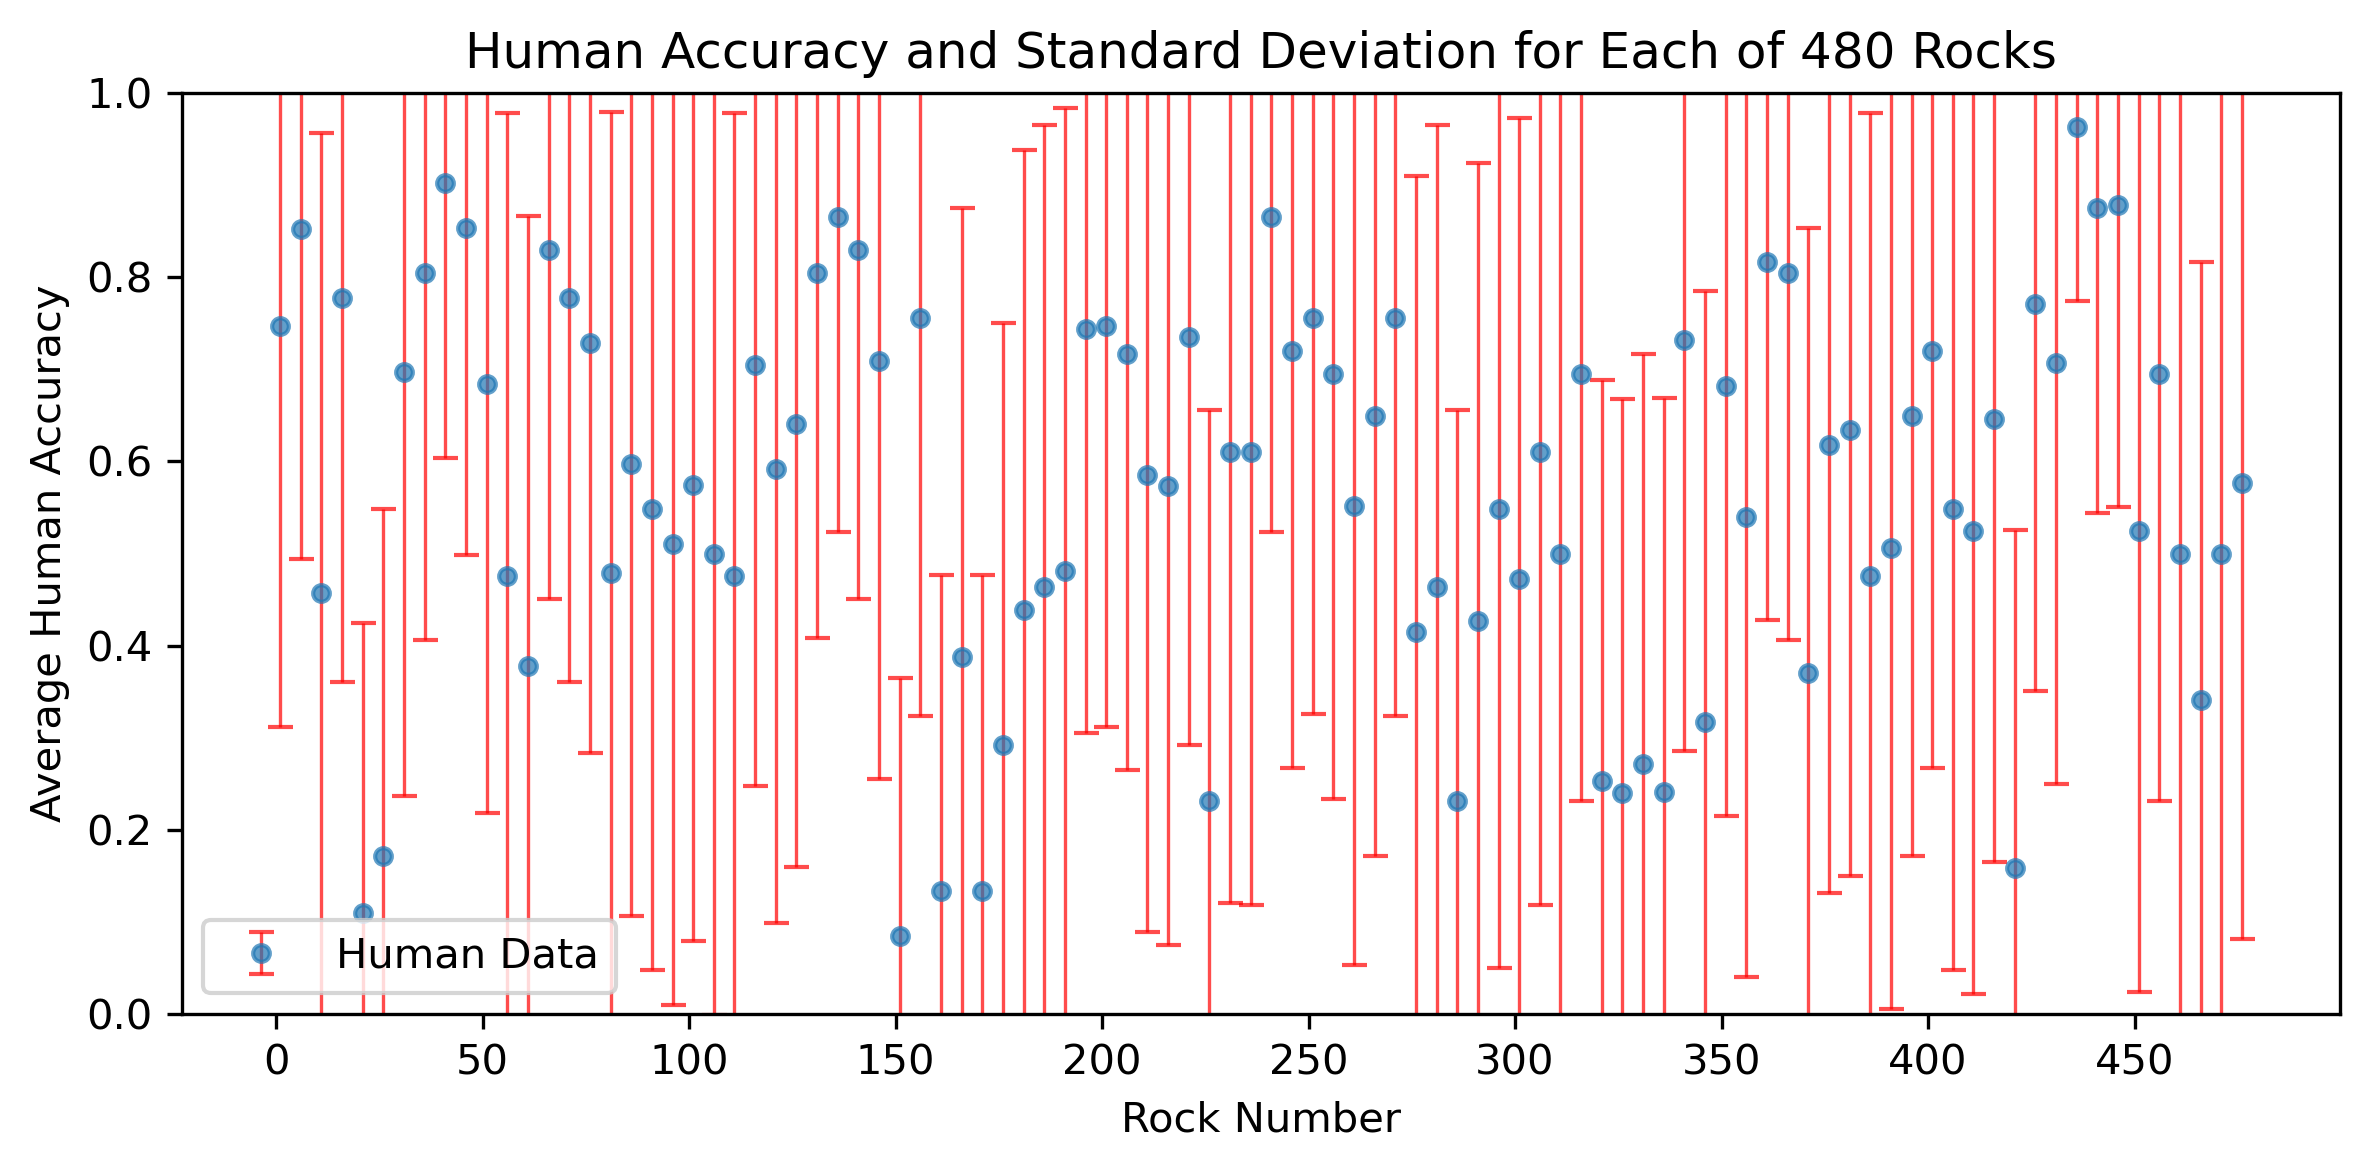

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4), dpi=300)

# Plot error bars (Since there are too many data, the graph looks messy. Here we draw a point every 10 data points.)
axes.errorbar(
    x=human_stats['rocknumber'][0::5],
    y=human_stats['human_accuracy'][0::5],
    yerr=human_stats['human_std'][0::5],
    fmt='o',
    ecolor='red',
    elinewidth=0.8,
    capsize=3,
    ls='none',        # no line connecting the dots
    alpha=0.7,
    markersize=4,
    label='Human Data'  # label for the legend
)

# Set labels and title
axes.set_xlabel('Rock Number')
axes.set_ylabel('Average Human Accuracy')
axes.set_title('Human Accuracy and Standard Deviation for Each of 480 Rocks')
axes.set_ylim(0, 1)

# Optionally, show fewer x-axis ticks (every 50 rocks)
axes.set_xticks(range(0, 481, 50))

# Add legend
axes.legend()

plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import classification_report

print("=== Classification Report: Training Set ===")
print(classification_report(y_train, y_train_pred, zero_division=0))

print("=== Classification Report: Validation Set ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

print("=== Classification Report: Test Set ===")
print(classification_report(y_test, y_test_pred, zero_division=0))


=== Classification Report: Training Set ===
              precision    recall  f1-score   support

           1       0.83      0.79      0.81       100
           2       0.75      0.83      0.79       100
           3       0.82      0.78      0.80       100

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300

=== Classification Report: Validation Set ===
              precision    recall  f1-score   support

           1       0.84      0.87      0.85        30
           2       0.74      0.77      0.75        30
           3       0.79      0.73      0.76        30

    accuracy                           0.79        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.79      0.79      0.79        90

=== Classification Report: Test Set ===
              precision    recall  f1-score   support

           1       0.81      0.73      0.77        30

The ensemble model achieved an overall accuracy of 80% on training, 79% on validation, and 77% on the test set. Per-label metrics (precision, recall, F1-score) are consistently high across all classes. In contrast, human accuracy is considerably lower—approximately 56% on training and 60% on test data. This indicates that the ensemble method substantially outperforms human judgment in classifying the rocks. The stable performance across splits suggests that the model generalizes well, capturing the underlying patterns effectively. Overall, these results highlight the potential of machine learning approaches to improve classification accuracy compared to human performance.